# PI3 R

### Carregar bibliotecas necessárias

In [14]:
library(Hmisc)
library(ggplot2)
library(corrplot)

### Leitura do CSV

In [4]:
df <- read.csv("/content/Dados_baixada.csv",
               fileEncoding = "latin1",
               sep = ";",
               dec = ",")

In [5]:
head(df, n =1)

,Municipio,CodPonto,SEQID,SistHidrico,Coleta_Data,Cloreto.Total,Condutividade,Escherichia.coli..,Fósforo.Total,Oxigênio.Dissolvido,Sólido.Dissolvido.Total,Sólido.Total,Temperatura.da.Água,Turbidez,pH
,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,CUBATAO,CFUG02900,208,Canal de Fuga II da UHE Henry Borden - CFUG,14/01/2016,12.5,151,12,0.007,7.7,168,186,25.9,7.73,6.64


### Vetor de colunas

In [6]:
colunas <- c(
  "Cloreto.Total",
  "Condutividade",
  "Escherichia.coli..",
  "Fósforo.Total",
  "Oxigênio.Dissolvido",
  "Sólido.Dissolvido.Total",
  "Sólido.Total",
  "Temperatura.da.Água",
  "Turbidez",
  "pH"
)

# Converter colunas para numérico
df[colunas] <- lapply(df[colunas], function(x) as.numeric(as.character(x)))


### Loop para histogramas

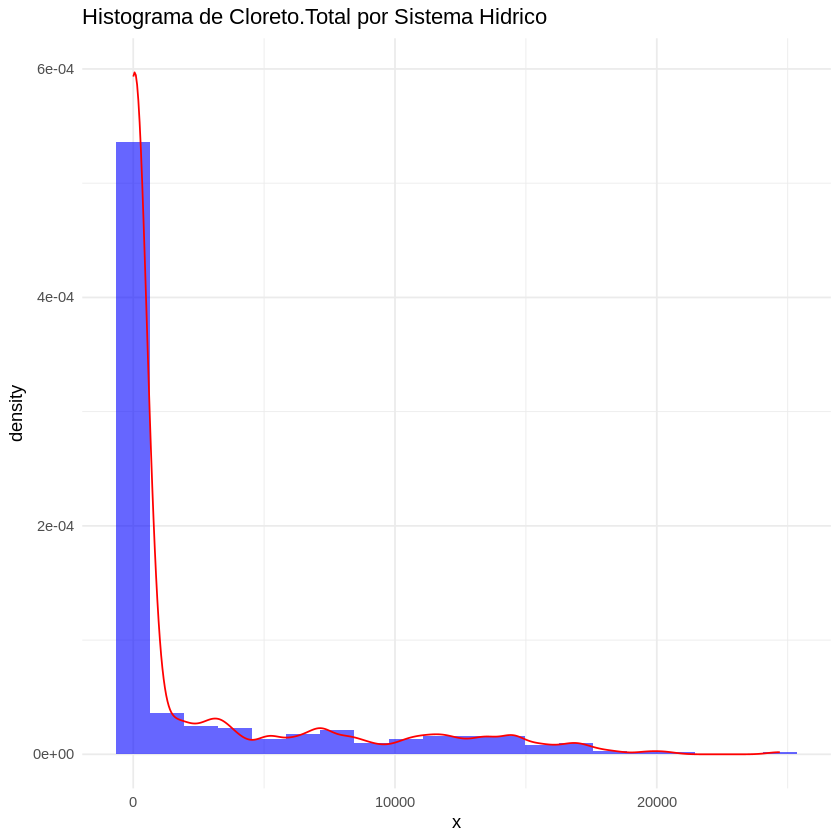

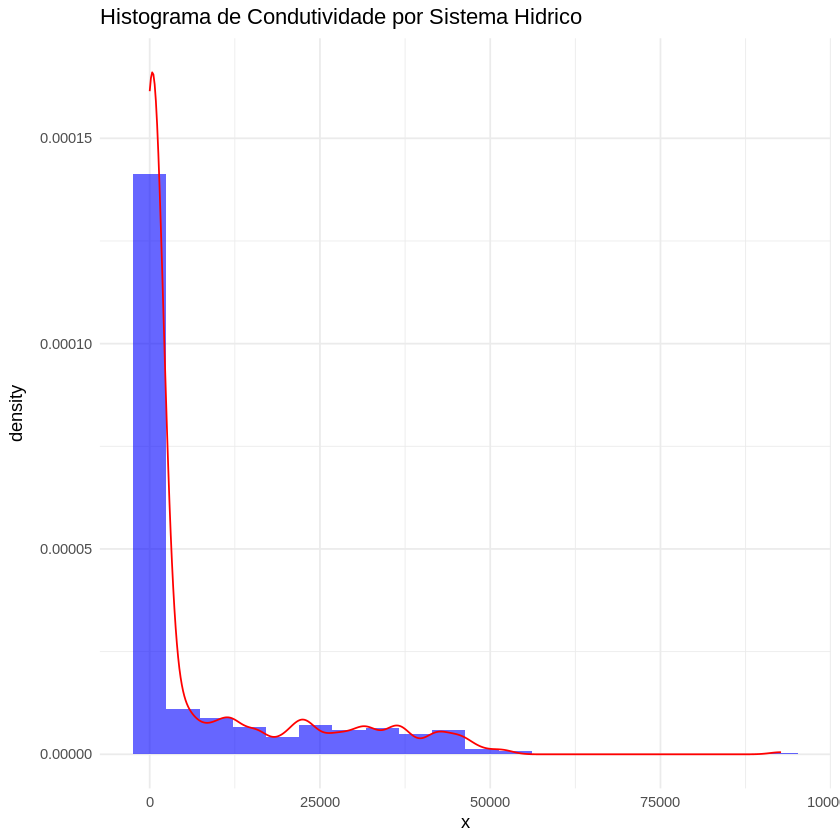

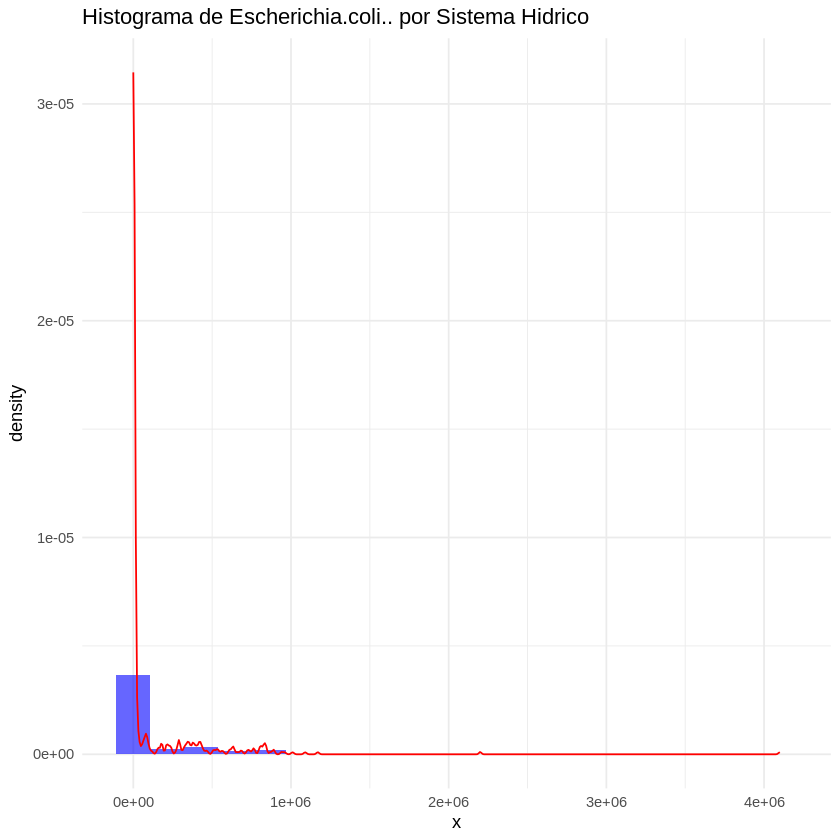

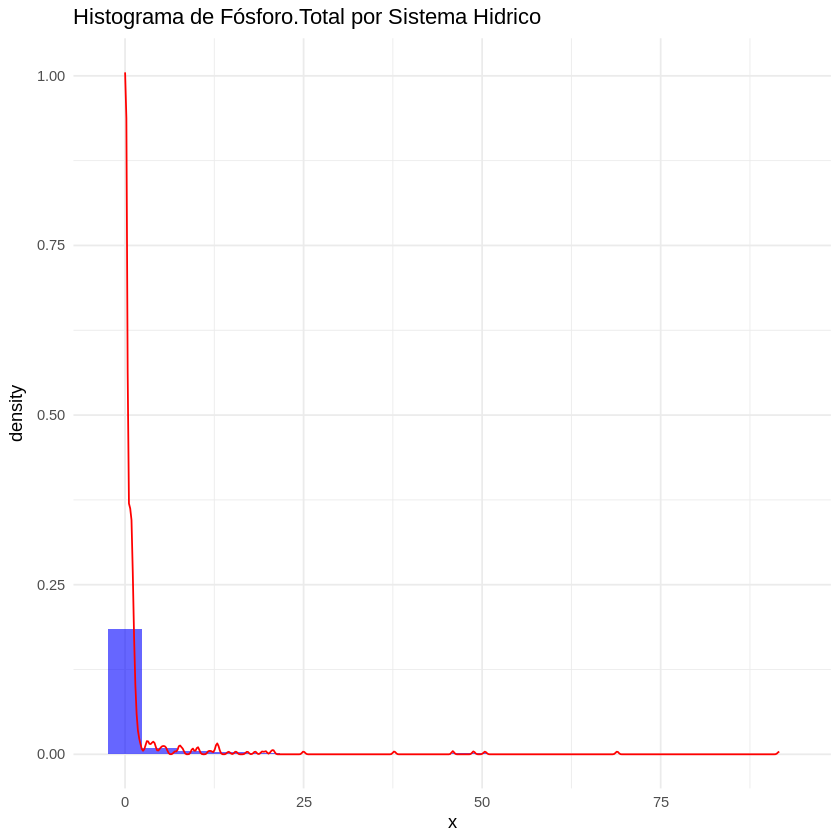

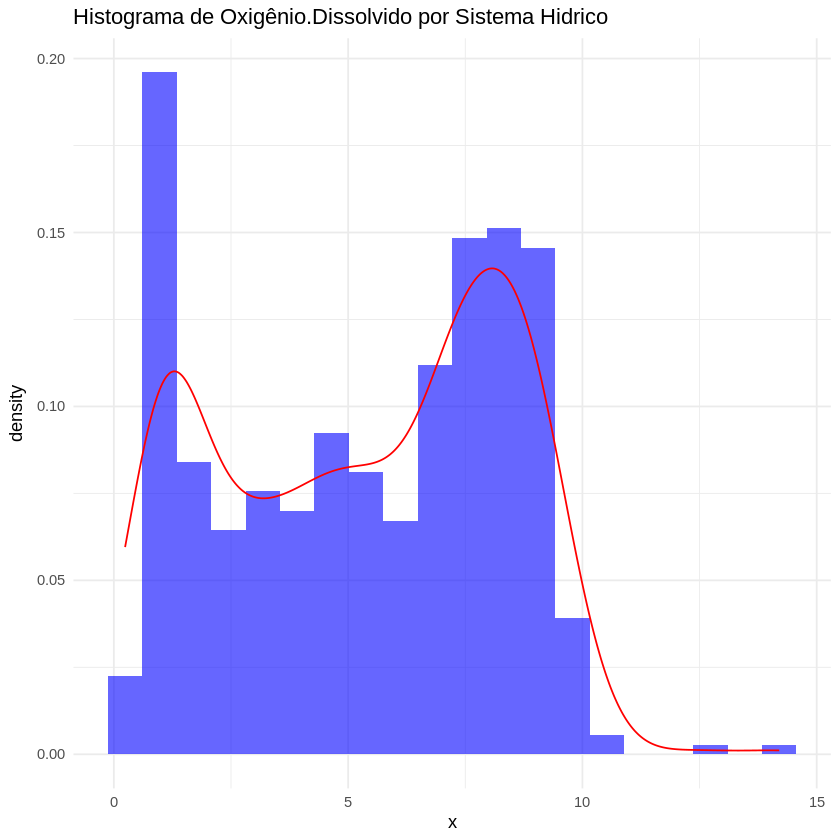

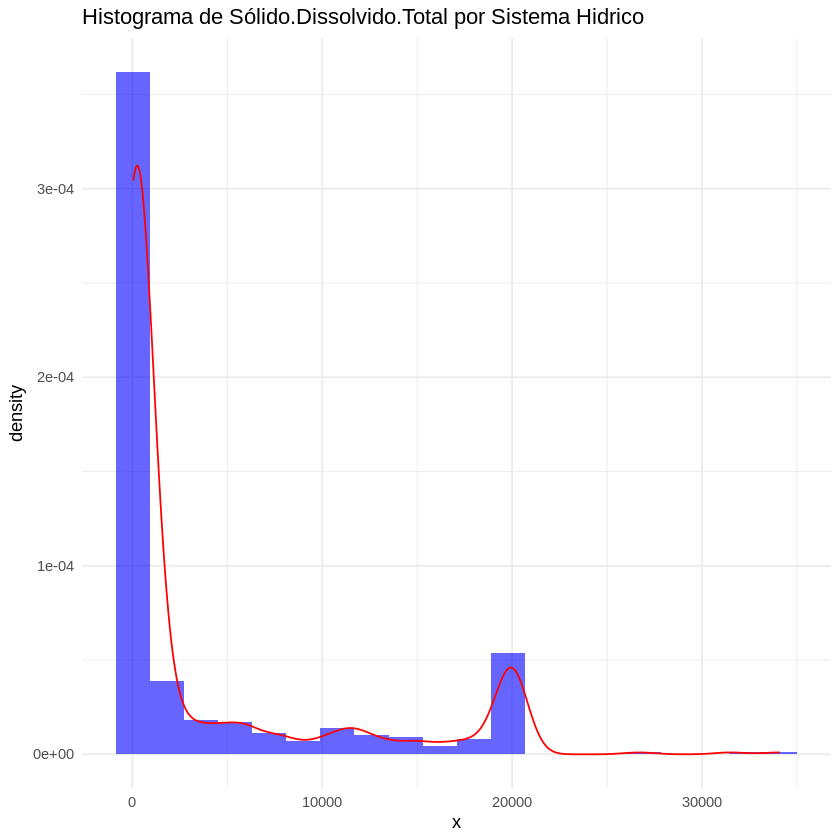

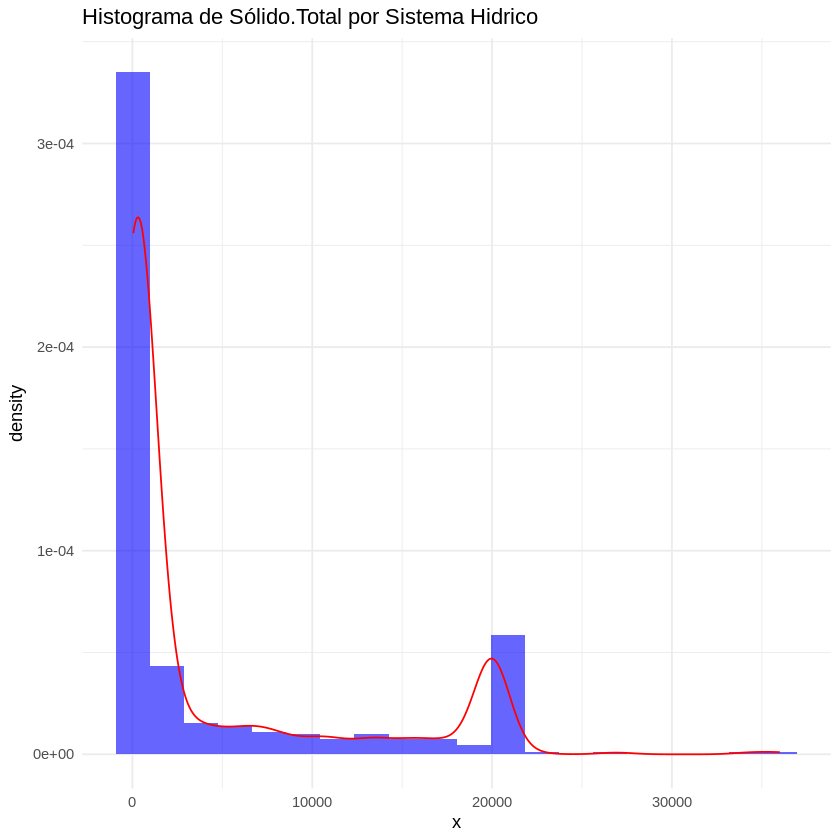

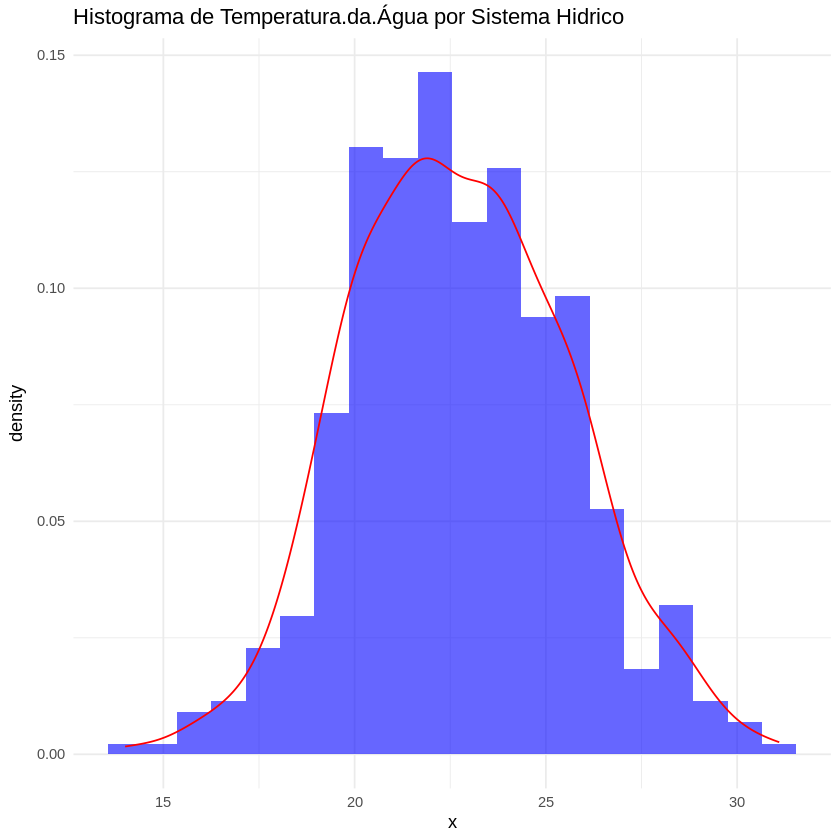

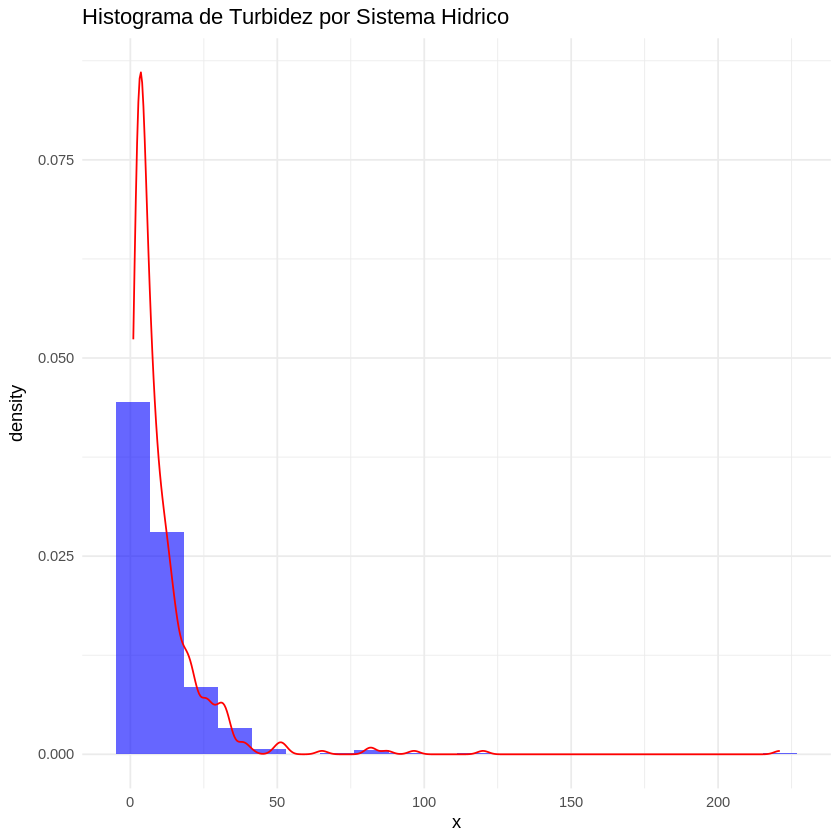

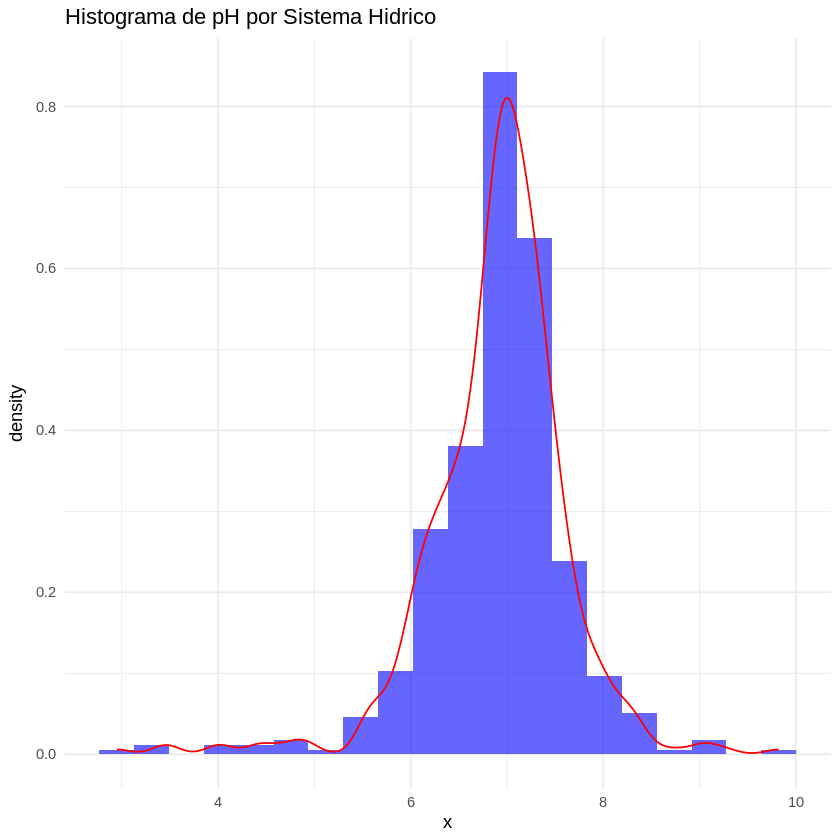

In [7]:
#for (col in colunas) {

  #p <- ggplot(df, aes_string(x = col)) +
    #geom_histogram(aes(y = ..density..), bins = 20, fill = "blue", alpha = 0.6) +
    #geom_density(color = "red") +
    #ggtitle(paste("Histograma de", col, "por Sistema Hidrico")) +
    #theme_minimal()

  #print(p)
#}

for (col in colunas) {

  dados <- df[[col]]
  dados <- dados[is.finite(dados)]  # remove NA, NaN, Inf

  p <- ggplot(data.frame(x = dados), aes(x = x)) +
    geom_histogram(aes(y = after_stat(density)), bins = 20, fill = "blue", alpha = 0.6) +
    geom_density(color = "red") +
    ggtitle(paste("Histograma de", col, "por Sistema Hidrico")) +
    theme_minimal()

  print(p)
}

### Variáveis normais

In [8]:
Normal <- c(
  "Temperatura.da.Água",
  "pH"
)

for (norm in Normal) {
  dados <- df[[norm]]

  mu <- mean(dados, na.rm = TRUE)
  sigma <- sd(dados, na.rm = TRUE)

  cat(paste("Média", norm, ":", mu, "\n"))
  cat(paste("Desvio padrão", norm, ":", sigma, "\n"))
}



Média Temperatura.da.Água : 22.7437703265638 
Desvio padrão Temperatura.da.Água : 2.84879569753431 
Média pH : 6.90966442985802 
Desvio padrão pH : 0.723431922613575 


### Variaveis exponenciais

Lambda ( Cloreto.Total ): 0.000405655390801858 
Lambda ( Condutividade ): 0.000133095358058032 


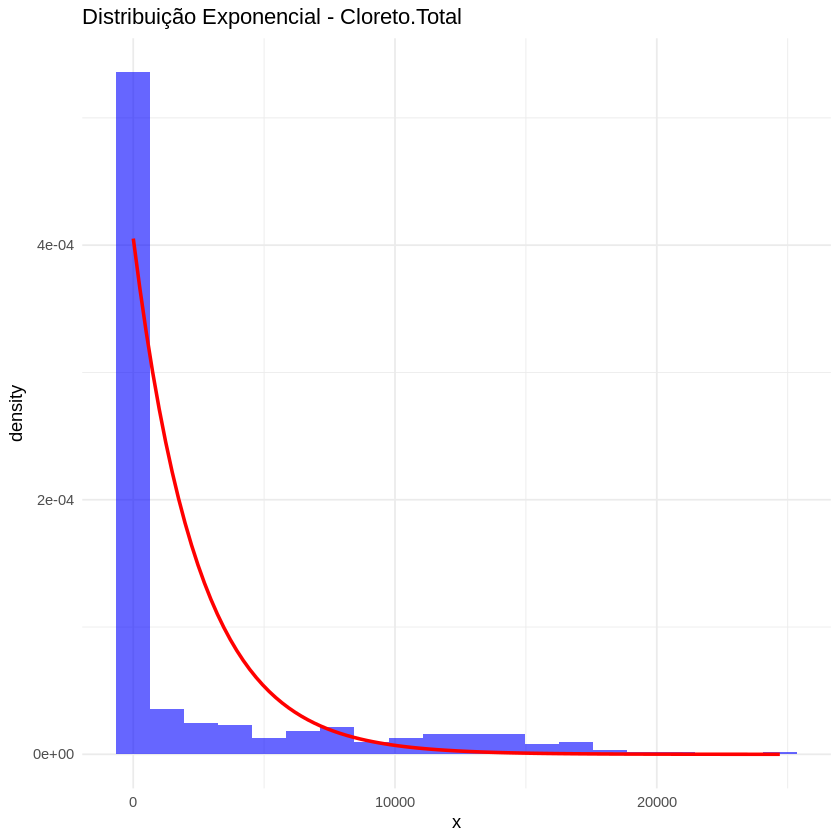

Lambda ( Escherichia.coli.. ): 8.40659553213473e-06 


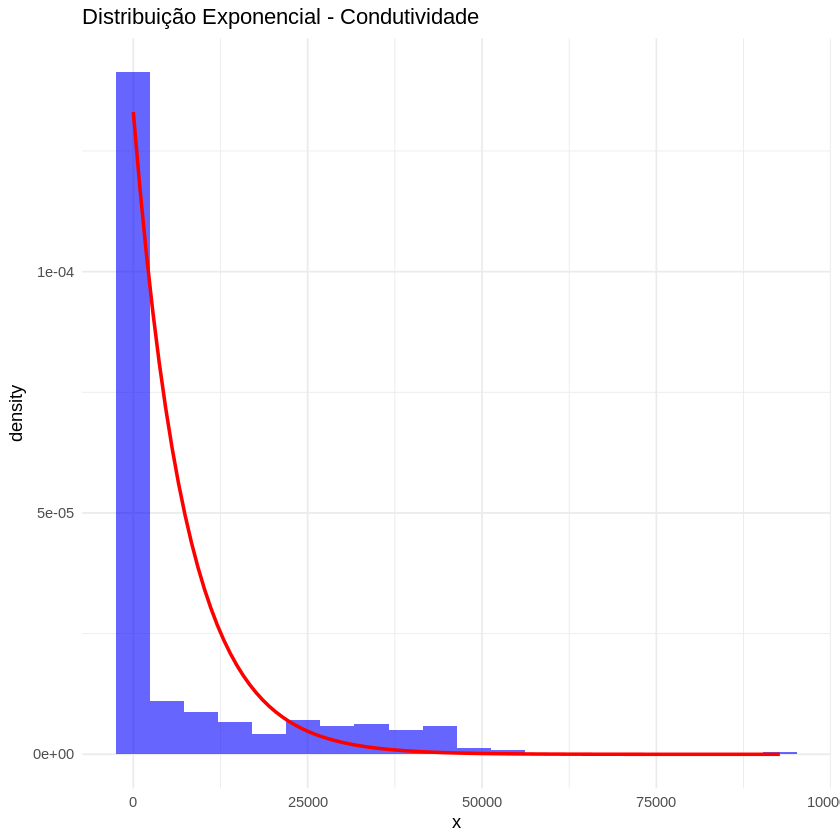

Lambda ( Fósforo.Total ): 0.509905340081449 


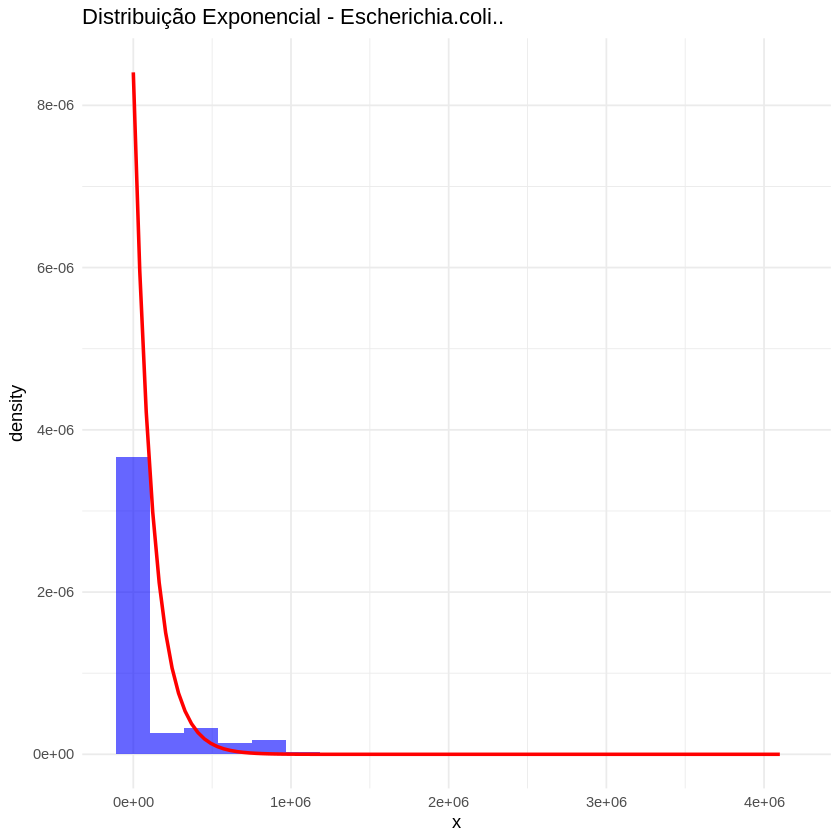

Lambda ( Sólido.Dissolvido.Total ): 0.000247270413308351 


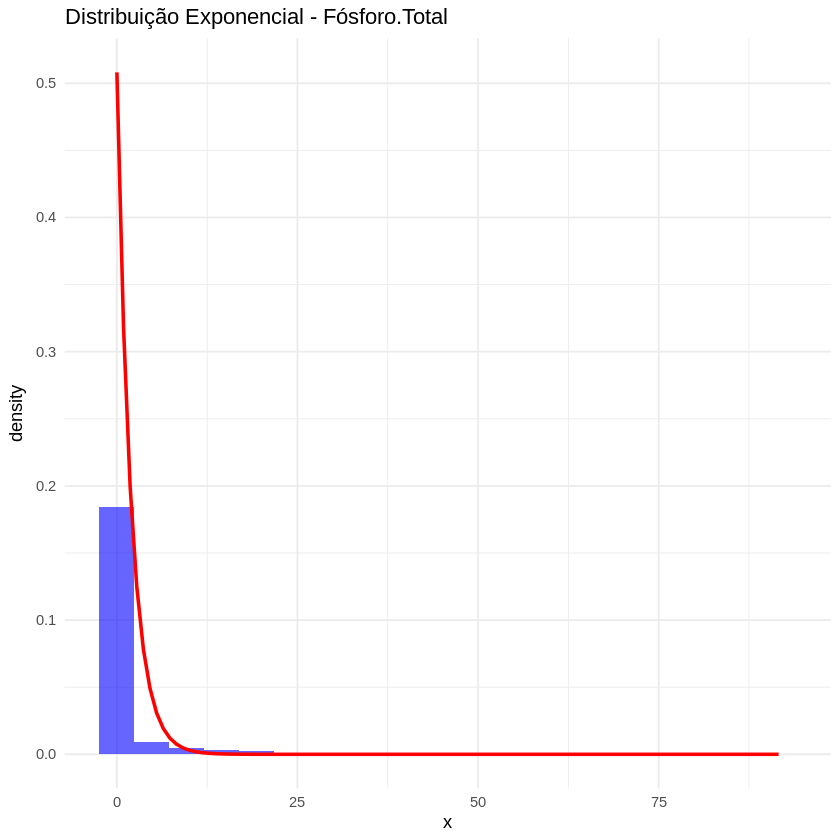

Lambda ( Sólido.Total ): 0.000228224450893706 


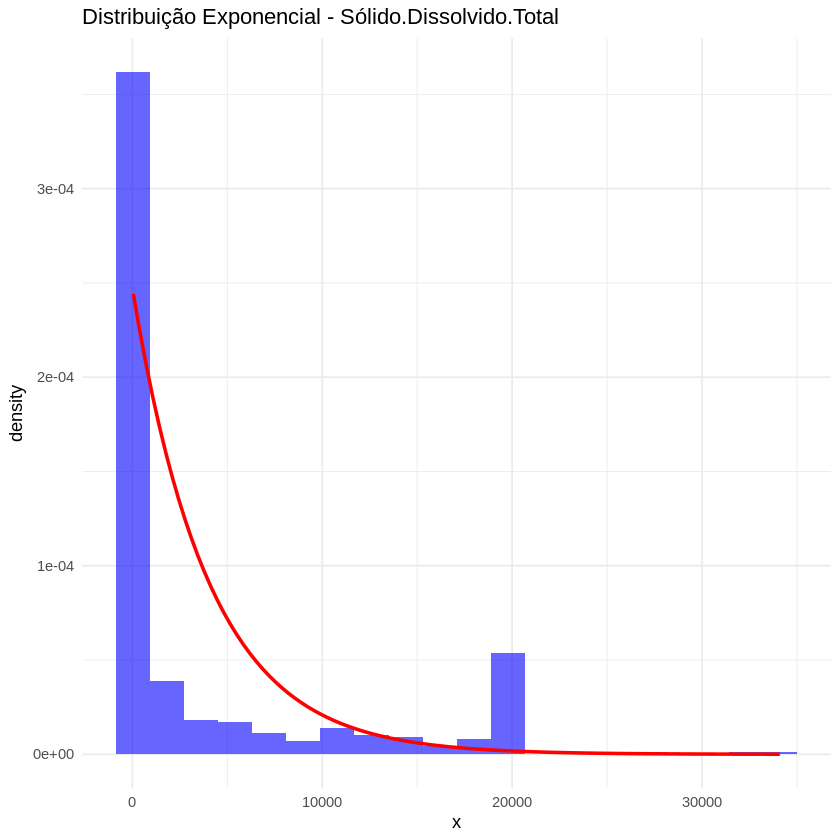

Lambda ( Turbidez ): 0.0913235384016501 


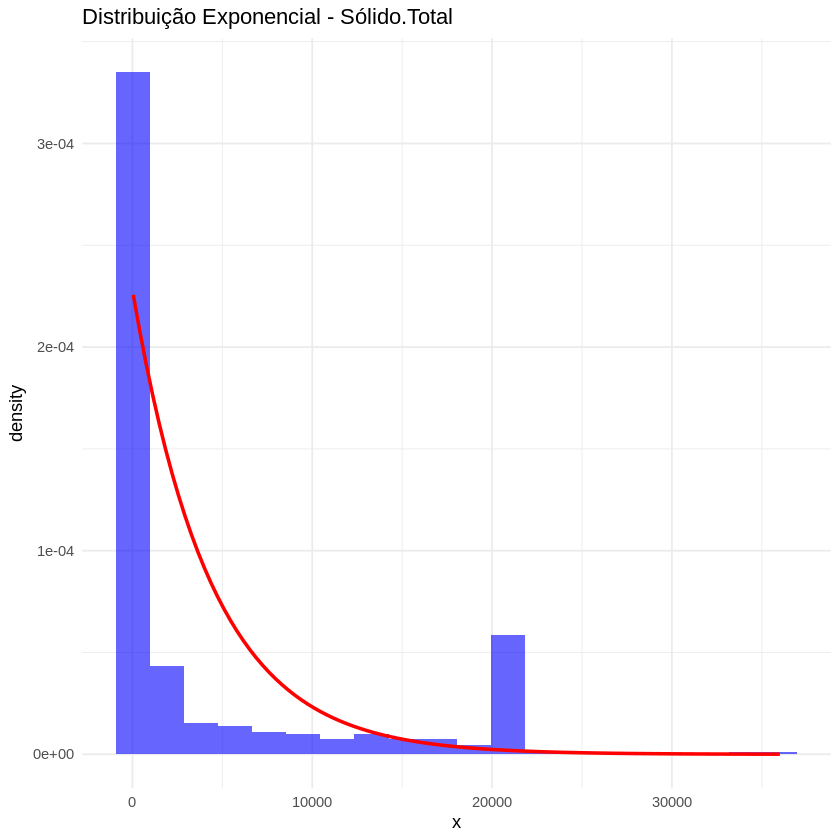

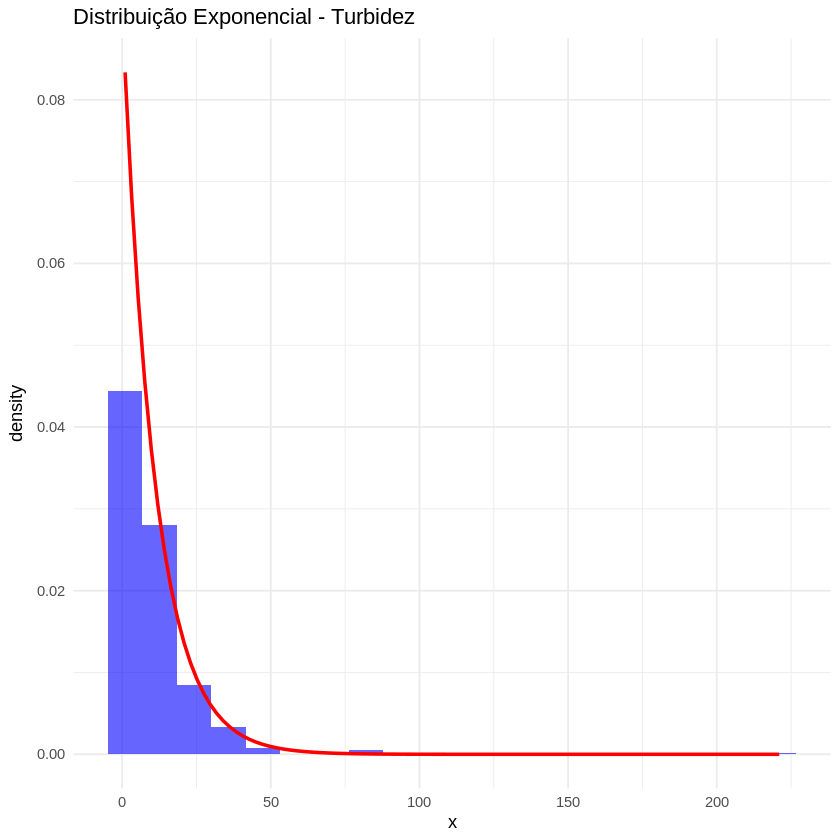

In [9]:
Exponencial = c(
  "Cloreto.Total",
  "Condutividade",
  "Escherichia.coli..",
  "Fósforo.Total",
  "Sólido.Dissolvido.Total",
  "Sólido.Total",
  "Turbidez"
)

for (col in Exponencial) {

  dados <- df[[col]]
  dados <- dados[is.finite(dados) & dados > 0]

  lambda <- 1 / mean(dados, na.rm = TRUE)

  cat(paste("Lambda (", col, "):", lambda, "\n"))


  dados_df <- data.frame(x = dados)

  p <- ggplot(dados_df, aes(x = x)) +
    geom_histogram(aes(y = after_stat(density)), bins = 20, fill = "blue", alpha = 0.6) +
    stat_function(fun = dexp, args = list(rate = lambda), color = "red", linewidth = 1) +
    ggtitle(paste("Distribuição Exponencial -", col)) +
    theme_minimal()

  print(p)
}




### Matriz de correlação

In [11]:
# Selecionar colunas
cols <- c(
  "Cloreto.Total",
  "Condutividade",
  "Escherichia.coli..",
  "Fósforo.Total",
  "Sólido.Dissolvido.Total",
  "Sólido.Total",
  "Turbidez"
)

# Filtrar apenas essas colunas
df_corr <- df[cols]

# Converter para numérico (garantia)
df_corr <- as.data.frame(lapply(df_corr, function(x) as.numeric(as.character(x))))

# Remover linhas com NA
df_corr <- na.omit(df_corr)

# Matriz de correlação de Pearson
cor_matrix <- cor(df_corr, method = "pearson")

# Mostrar matriz no console
print(cor_matrix)





                        Cloreto.Total Condutividade Escherichia.coli..
Cloreto.Total              1.00000000    0.90624059        -0.11724082
Condutividade              0.90624059    1.00000000        -0.10650468
Escherichia.coli..        -0.11724082   -0.10650468         1.00000000
Fósforo.Total             -0.11842539   -0.10680980        -0.05060801
Sólido.Dissolvido.Total    0.95541623    0.89958189        -0.10682629
Sólido.Total               0.94337042    0.89433534        -0.10432251
Turbidez                  -0.06778737   -0.04146437         0.34887732
                        Fósforo.Total Sólido.Dissolvido.Total Sólido.Total
Cloreto.Total             -0.11842539              0.95541623   0.94337042
Condutividade             -0.10680980              0.89958189   0.89433534
Escherichia.coli..        -0.05060801             -0.10682629  -0.10432251
Fósforo.Total              1.00000000             -0.09914706  -0.09918108
Sólido.Dissolvido.Total   -0.09914706              1.0000

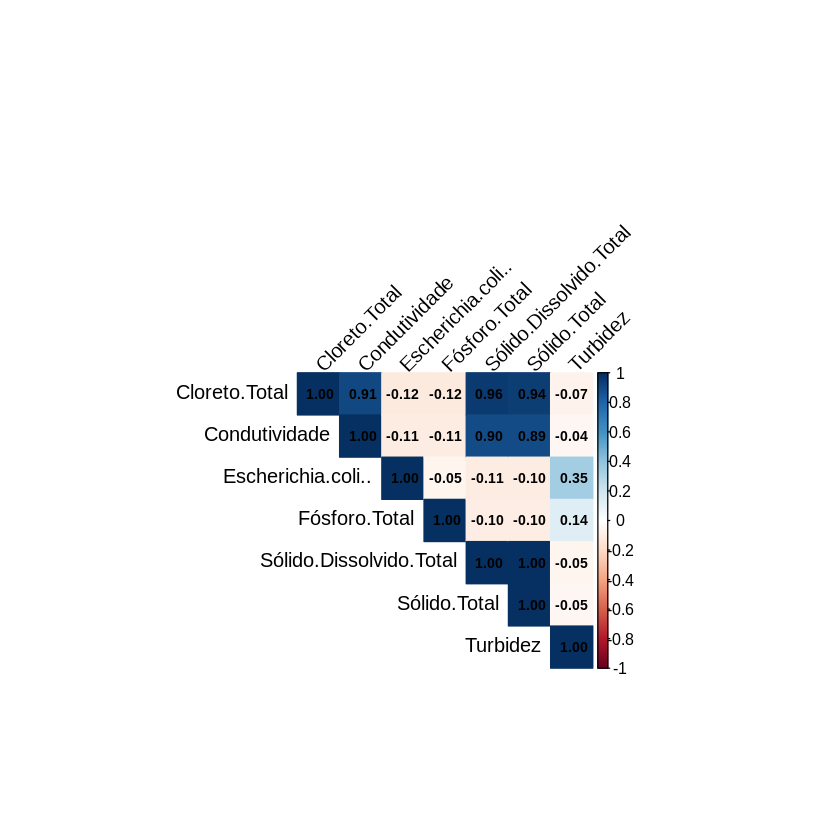

In [12]:
# Plotar heatmap
corrplot(cor_matrix,
         method = "color",
         type = "upper",
         tl.col = "black",
         tl.srt = 45,
         addCoef.col = "black",
         number.cex = 0.7)

In [21]:
res <- rcorr(as.matrix(df_corr), type = "pearson")



# Matriz de p-valores
p_matrix <- res$P

# Mostrar no console
print(p_matrix)

                        Cloreto.Total Condutividade Escherichia.coli..
Cloreto.Total                      NA    0.00000000       1.096758e-02
Condutividade              0.00000000            NA       2.092194e-02
Escherichia.coli..         0.01096758    0.02092194                 NA
Fósforo.Total              0.01018122    0.02055586       2.735448e-01
Sólido.Dissolvido.Total    0.00000000    0.00000000       2.053623e-02
Sólido.Total               0.00000000    0.00000000       2.370912e-02
Turbidez                   0.14227539    0.36976252       6.661338e-15
                        Fósforo.Total Sólido.Dissolvido.Total Sólido.Total
Cloreto.Total             0.010181223              0.00000000   0.00000000
Condutividade             0.020555855              0.00000000   0.00000000
Escherichia.coli..        0.273544819              0.02053623   0.02370912
Fósforo.Total                      NA              0.03163196   0.03157326
Sólido.Dissolvido.Total   0.031631957                    

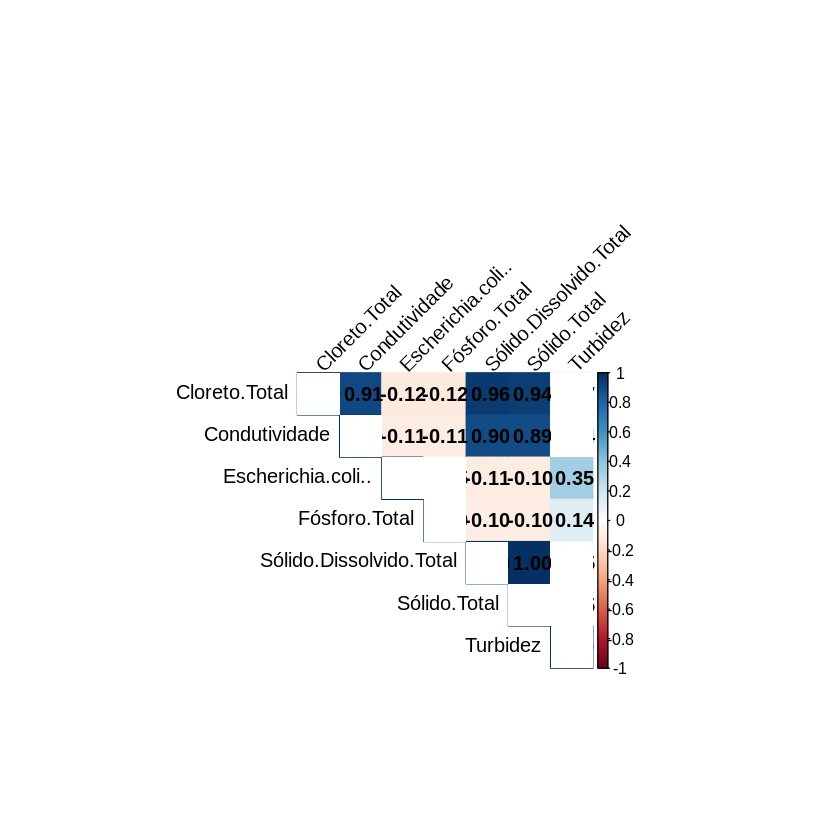

In [23]:
diag(p_matrix)[is.na(diag(p_matrix))] <- 1

corrplot(cor_matrix,
         method = "color",
         type = "upper",
         tl.col = "black",
         tl.srt = 45,
         addCoef.col = "black",
         p.mat = p_matrix,
         sig.level = 0.05,
         insig = "blank")